# Evaluacion de Calidad de Dataset ChatML para SLMs Agricolas

**Proyecto:** Asistente Virtual Inteligente Agricola - FarmifAI  
**Universidad del Cauca - Dpto. Telematica**  

## Descripcion

Este notebook evalua la calidad de un dataset en formato ChatML disenado para
entrenar un Small Language Model (SLM) que genera recomendaciones y responde
preguntas agricolas.

### Estructura del dataset evaluado

Cada registro del JSONL tiene la siguiente estructura:

```json
{
  "messages": [
    {"role": "system", "content": "..."},
    {"role": "user", "content": "<knowledge>...\n</knowledge>\n\n[Pregunta del usuario]"},
    {"role": "assistant", "content": "<reasoning>...\n</reasoning>\n<answer>...\n</answer>"}
  ]
}
```

### Grupos de metricas

| Grupo | Descripcion |
|---|---|
| Grupo 1 | Integridad estructural ChatML |
| Grupo 2 | Deduplicacion |
| Grupo 3 | Diversidad lexica (preguntas y respuestas) |
| Grupo 4 | Similitud semantica entre preguntas |
| Grupo 5 | Balance de categorias: Entropia de Shannon Normalizada y CV (cultivos desde JSON externo) |
| Grupo 6 | Complejidad de respuestas |
| Grupo 7 | Validacion de formato (etiquetas reasoning/answer) |
| Grupo 8 | Cobertura de vocabulario de dominio agricola |
| Grupo 9 | Self-BLEU y Self-ROUGE |

## 0. Instalacion de dependencias

In [16]:
%%capture
!pip install datasketch sentence-transformers nltk rouge-score \
            scikit-learn matplotlib seaborn tqdm pandas numpy lexicalrichness jinja2


In [17]:
import json
import re
import hashlib
import math
import warnings
import datetime
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import nltk
from nltk.util import ngrams
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer

from datasketch import MinHash, MinHashLSH
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from scipy.stats import chisquare

try:
    from lexicalrichness import LexicalRichness
    MTLD_AVAILABLE = True
except ImportError:
    MTLD_AVAILABLE = False
    print('[WARN] lexicalrichness no disponible. pip install lexicalrichness')

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Dependencias cargadas OK')

Dependencias cargadas OK


## 1. Carga del dataset ChatML y Estadisticas de Cultivo

Sube los dos archivos requeridos cuando aparezca el selector:
1. El archivo JSONL del dataset en formato ChatML.
2. El archivo JSON con las estadisticas por cultivo (ej: `estadisticas_dataset.json`).

In [18]:
from google.colab import files

print('1. Selecciona tu archivo JSONL (formato ChatML):')
uploaded_jsonl = files.upload()
jsonl_filename = list(uploaded_jsonl.keys())[0]

print('2. Selecciona tu archivo JSON de estadisticas (ej. estadisticas_dataset.json):')
uploaded_stats = files.upload()
stats_filename = list(uploaded_stats.keys())[0]

raw_records = []
with open(jsonl_filename, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        line = line.strip()
        if not line:
            continue
        try:
            raw_records.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f'  ERROR linea {i+1}: {e}')

with open(stats_filename, 'r', encoding='utf-8') as f:
    stats_data = json.load(f)
crop_stats = stats_data.get('por_cultivo', {})


def parse_chatml(record):
    """Extrae campos estructurados de un registro ChatML."""
    msgs = record.get('messages', [])

    system_content = ''
    user_content = ''
    assistant_content = ''

    for msg in msgs:
        role = msg.get('role', '')
        content = msg.get('content', '')
        if role == 'system':
            system_content = content
        elif role == 'user':
            user_content = content
        elif role == 'assistant':
            assistant_content = content

    # Extraer pregunta limpia (sin <knowledge> si existe)
    pregunta = user_content
    knowledge = ''
    if '<knowledge>' in user_content and '</knowledge>' in user_content:
        km = re.search(r'<knowledge>(.*?)</knowledge>',
                       user_content, re.DOTALL)
        if km:
            knowledge = km.group(1).strip()
        pregunta = re.sub(r'<knowledge>.*?</knowledge>\s*',
                          '', user_content, flags=re.DOTALL).strip()

    # Extraer reasoning y answer del asistente
    reasoning = ''
    answer = ''
    rm = re.search(r'<reasoning>(.*?)</reasoning>',
                   assistant_content, re.DOTALL)
    am = re.search(r'<answer>(.*?)</answer>', assistant_content, re.DOTALL)
    if rm:
        reasoning = rm.group(1).strip()
    if am:
        answer = am.group(1).strip()

    return {
        'pregunta': pregunta,
        'knowledge': knowledge,
        'reasoning': reasoning,
        'answer': answer,
        'assistant_full': assistant_content,
        'system': system_content,
        'user_raw': user_content,
        'n_messages': len(msgs),
        'roles_ok': [m.get('role', '') for m in msgs] == ['system', 'user', 'assistant'] if len(msgs) == 3 else False,
    }


parsed = [parse_chatml(r) for r in raw_records]
df = pd.DataFrame(parsed)
print(f'Registros cargados del dataset: {len(df):,}')
print(f'Cultivos cargados para estadisticas: {len(crop_stats)}')
print(f'Columnas de datos estructurados: {list(df.columns)}')
df.head(3)

1. Selecciona tu archivo JSONL (formato ChatML):


Saving dataset_agricola.jsonl to dataset_agricola (1).jsonl
2. Selecciona tu archivo JSON de estadisticas (ej. estadisticas_dataset.json):


Saving estadisticas_dataset.json to estadisticas_dataset (1).json
Registros cargados del dataset: 6,966
Cultivos cargados para estadisticas: 50
Columnas de datos estructurados: ['pregunta', 'knowledge', 'reasoning', 'answer', 'assistant_full', 'system', 'user_raw', 'n_messages', 'roles_ok']


,pregunta,knowledge,reasoning,answer,assistant_full,system,user_raw,n_messages,roles_ok
0,"Oiga, yo tengo una tierrita por Majagual, Sucr...",Geología: La geología del departamento de Sucr...,El conocimiento indica que en los municipios d...,"Mire, por esa zona de Majagual la tierra es ba...",<reasoning>\nEl conocimiento indica que en los...,Eres un asistente inteligente. Analiza la info...,<knowledge>\nGeología: La geología del departa...,3,True
1,"Don, mire, yo tengo un pedazo de tierra como p...",Geología: El cultivo de cacao requiere suelos ...,El usuario describe un suelo que se encharca c...,"Mire, parce, esa tierra que se encharca cuando...",<reasoning>\nEl usuario describe un suelo que ...,Eres un asistente inteligente. Analiza la info...,<knowledge>\nGeología: El cultivo de cacao req...,3,True
2,"Don, yo tengo una parcela de cacao aquí en Suc...",Radiación solar: La radiación solar es la ener...,El fragmento indica que en Sucre la radiación ...,"Mire, parce, el cacao es una mata que no aguan...",<reasoning>\nEl fragmento indica que en Sucre ...,Eres un asistente inteligente. Analiza la info...,<knowledge>\nRadiación solar: La radiación sol...,3,True


## 2. Configuracion global

In [19]:
COL_PREGUNTA = 'pregunta'
COL_ANSWER = 'answer'
COL_REASONING = 'reasoning'
COL_KNOWLEDGE = 'knowledge'
COL_ASSISTANT = 'assistant_full'

TERMINOS_DOMINIO = [
    # --- Proceso y fermentacion ---
    'fermentacion', 'ferment', 'proceso', 'beneficio', 'postcosecha',
    'anaerobico', 'anaerobia', 'aerobi', 'lactico', 'acetico',
    'maceracion', 'carbonica', 'espontaneo', 'inoculado', 'extendido',
    'sumergido', 'protocolo', 'lavado', 'honey', 'natural', 'tradicional',

    # --- Cafe y campo ---
    'cafe', 'caficultor', 'finca', 'lote', 'cosecha', 'mitaca',
    'pulpa', 'compostaje', 'recoleccion', 'peinado', 'floracion', 'fruto',
    'crecimiento', 'lluvia', 'patio',

    # --- Variedades y cultivares ---
    'arabica', 'geisha', 'castillo', 'caturra', 'bourbon', 'tabi',
    'typica', 'cenicafe', 'maragogype', 'java', 'catimor', 'cultivar',

    # --- Variables de proceso ---
    'ph', 'brix', 'temperatura', 'humedad', 'oxigeno', 'redox',
    'duracion', 'altitud', 'horas', 'msnm',

    # --- Equipos e instrumentos ---
    'tanque', 'recipiente', 'airlock', 'valvula', 'termometro',
    'refractometro', 'medidor', 'sensor', 'biorreactor', 'silo',
    'despulpadora', 'lavadora', 'despulpado', 'secado', 'agitador',
    'becolsub', 'ecomill', 'biodigestor', 'densimetrica', 'gravimetrica',
    'glicol', 'barril', 'instrumento', 'co2', 'inyeccion', 'agtron',

    # --- Microorganismos ---
    'levadura', 'bacteria', 'microorganismo', 'hongo', 'saccharomyces',
    'lactobacillus', 'leuconostoc', 'acetobacter', 'pectinasa',
    'fusarium', 'aspergillus', 'penicillium', 'pediococcus',

    # --- Metabolitos y bioquimica ---
    'metabolito', 'acido', 'alcohol', 'ester', 'aldehido', 'glucosa',
    'fructosa', 'etanol', 'glucolisis', 'piruvato', 'maillard',
    'lactato', 'acetato', 'succinico', 'malico', 'citrico', 'quinico',
    'diacetilo', 'guaiacol', 'furfural', 'isoamil', 'gaba',
    'melanoidina', 'pirazina', 'furano', 'strecker', 'ehrlich',
    'tricloroanisol', 'tca', 'ocratoxina', 'ota', 'micotoxina', 'fumonisin',
    'oxidacion', 'deshidrogenasa', 'pqq', 'enzima',
    'malolactico', 'homofermentativo', 'heterofermentativo',
    'azucar', 'sacarosa', 'cafeina',

    # --- Defectos ---
    'defecto', 'vinagre', 'avinagrado', 'moho', 'contaminacion',
    'sobrefermentacion', 'subfermentacion', 'fenolico', 'terroso',

    # --- Perfil sensorial y calidad ---
    'sensorial', 'aroma', 'sabor', 'taza', 'catacion', 'cupping',
    'acidez', 'cuerpo', 'dulzura', 'uniformidad', 'fragancia',
    'notes', 'perfil', 'atributo', 'puntaje', 'sca', 'especialidad',
    'grado', 'tueste',

    # --- Alertas, diagnosticos y control ---
    'alerta', 'alertas', 'diagnostico', 'sintoma', 'urgencia',
    'correctiva', 'umbral', 'rango', 'monitoreo',

    # --- Estructura del grano ---
    'mucilago', 'pergamino', 'cereza', 'grano', 'endocarpo',
    'mesocarpo', 'cascara', 'endospermo',

    # --- Inoculo y cultivo iniciador ---
    'inoculo', 'inoculacion',

    # --- Almacenamiento y embalaje ---
    'almacenamiento', 'bolsa', 'grainpro', 'estiba', 'infestacion', 'insecto',

    # --- Agua, normas ambientales y certificacion ---
    'agua', 'aguas', 'norma', 'certificacion', 'sello', 'estandar',
    'vertimiento', 'biogas', 'smta', 'fafa', 'dbo', 'dqo',

    # --- Zonas geograficas ---
    'cauca', 'huila', 'narino', 'inza', 'popayan', 'cajibio',
    'timbio', 'tambo', 'zona', 'municipio', 'macizo', 'tierradentro',

    # --- Organizaciones y mercado ---
    'cooperativa', 'productor', 'asoinca', 'cosurca', 'caficauca',
    'mercado', 'precio', 'exportacion',

    # --- Normas y estandares especificos ---
    'ntc', 'iso', 'codex', 'resolucion', 'fnc', 'reglamento',

    # --- Clasificaciones de exportacion ---
    'excelso', 'supremo', 'ugq', 'premium',

    # --- Unidades de medida del beneficio ---
    'arroba', 'carga', 'saco', 'lata', 'cps',

    # --- Factores de conversion y clasificacion fisica ---
    'trilla', 'rendimiento', 'conversion', 'clasificacion', 'densidad', 'malla',

    # --- Plagas, enfermedades y resistencia ---
    'broca', 'roya', 'antestia', 'nematodo', 'cbd',

    # --- Terminos agricolas generales ---
    'cultivo', 'siembra', 'riego', 'fertilizacion', 'abono',
    'plaga', 'enfermedad', 'suelo', 'tierra', 'planta', 'mata',
    'semilla', 'parcela', 'campesino', 'agricultor', 'cosechero',
    'herbicida', 'fungicida', 'insecticida', 'pesticida', 'organico',
    'compost', 'lombriz', 'humus', 'mulch', 'cobertura',
    'poda', 'injerto', 'vivero', 'germinacion', 'trasplante',
    'surco', 'era', 'cama', 'drenaje', 'pendiente',
    'verano', 'invierno', 'sequia', 'helada', 'granizo',
    'tomate', 'papa', 'maiz', 'yuca', 'platano', 'cana',
    'arroz', 'frijol', 'cebolla', 'zanahoria', 'aguacate', 'cacao',
]

# Umbrales basados en literatura
UMBRAL_DUPLICADOS_EXACTOS = 0.01
UMBRAL_NEAR_DUPLICATES = 0.05
UMBRAL_TTR_MIN = 0.40
UMBRAL_MTLD_MIN = 40.0   # McCarthy & Jarvis (2010)
UMBRAL_FORMAT_ERROR = 0.02
UMBRAL_SELF_BLEU_MAX = 0.60
UMBRAL_BIGRAM_DIV_MIN = 0.70
MINHASH_THRESHOLD = 0.80
EMBEDDING_SAMPLE = 500
SELF_BLEU_SAMPLE = 200

REPORTE = {}
total = len(df)
print('Configuracion cargada.')

Configuracion cargada.


## 3. Integridad estructural ChatML (Grupo 1)
Referencia: Yu et al. ASE'24.

GRUPO 1: INTEGRIDAD ESTRUCTURAL CHATML
  [OK] Estructura roles (system/user/assistant): 6966 OK, 0 malformados (0.00%)
  [OK] Vacios en `pregunta`: 0 (0.00%)
  [OK] Vacios en `answer`: 0 (0.00%)
  [OK] Vacios en `reasoning`: 0 (0.00%)
  Preguntas < 10 chars: 0
  Preguntas > 1000 chars: 0
  Respuestas < 10 chars: 0
  Long. promedio pregunta:     178.4 chars | 34.0 tokens
  Long. promedio reasoning:    566.7 chars | 88.2 tokens
  Long. promedio answer:       805.7 chars | 150.1 tokens


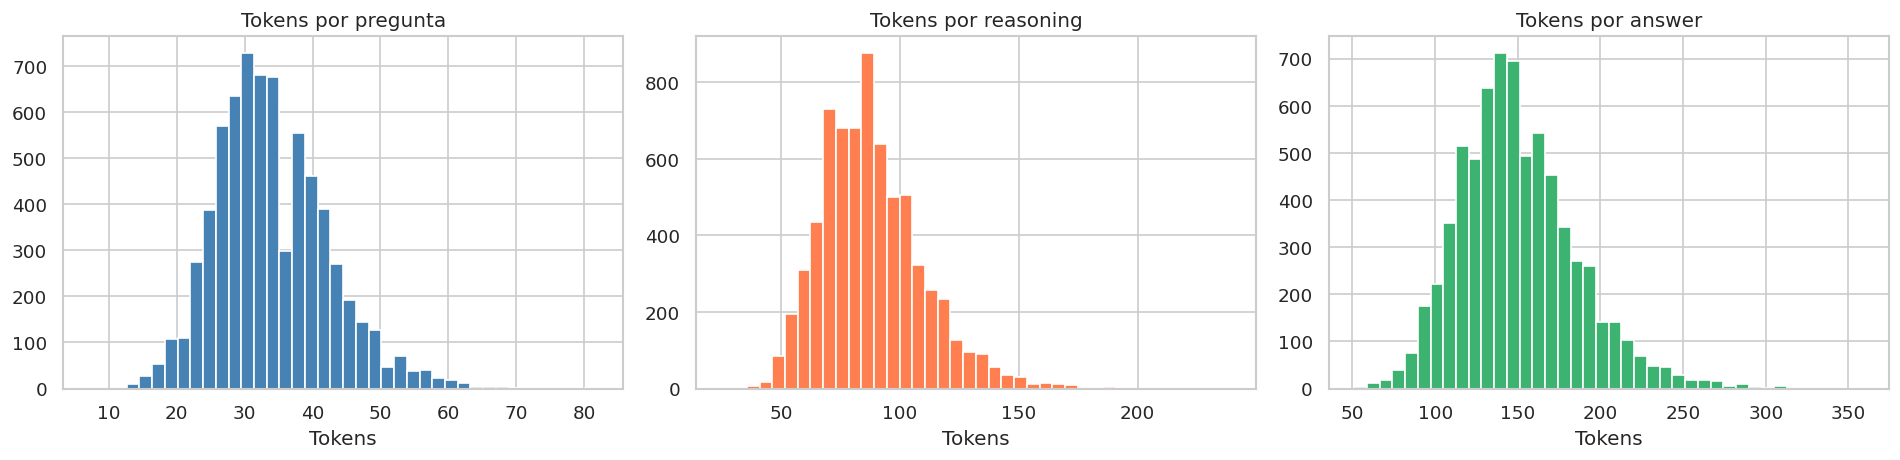

In [20]:
print('=' * 60)
print('GRUPO 1: INTEGRIDAD ESTRUCTURAL CHATML')
print('=' * 60)

# Validar estructura de mensajes
n_roles_ok = df['roles_ok'].sum()
n_roles_bad = total - n_roles_ok
tasa_roles_bad = n_roles_bad / total if total > 0 else 0
print(f'  [{"OK" if tasa_roles_bad == 0 else "WARN"}] Estructura roles (system/user/assistant): {n_roles_ok} OK, {n_roles_bad} malformados ({tasa_roles_bad*100:.2f}%)')

# Nulls y vacios
for col in [COL_PREGUNTA, COL_ANSWER, COL_REASONING]:
    n_null = df[col].isna().sum() + (df[col] == '').sum()
    print(f'  [{"OK" if n_null == 0 else "WARN"}] Vacios en `{col}`: {n_null} ({n_null/total*100:.2f}%)')

# Metricas de longitud
df['len_pregunta'] = df[COL_PREGUNTA].fillna('').apply(len)
df['len_answer'] = df[COL_ANSWER].fillna('').apply(len)
df['len_reasoning'] = df[COL_REASONING].fillna('').apply(len)
df['tokens_pregunta'] = df[COL_PREGUNTA].fillna(
    '').apply(lambda x: len(x.split()))
df['tokens_answer'] = df[COL_ANSWER].fillna('').apply(lambda x: len(x.split()))
df['tokens_reasoning'] = df[COL_REASONING].fillna(
    '').apply(lambda x: len(x.split()))

# Preguntas muy cortas o muy largas
short_q = (df['len_pregunta'] < 10).sum()
long_q = (df['len_pregunta'] > 1000).sum()
short_a = (df['len_answer'] < 10).sum()
print(f'  Preguntas < 10 chars: {short_q}')
print(f'  Preguntas > 1000 chars: {long_q}')
print(f'  Respuestas < 10 chars: {short_a}')
print(
    f'  Long. promedio pregunta:     {df["len_pregunta"].mean():.1f} chars | {df["tokens_pregunta"].mean():.1f} tokens')
print(
    f'  Long. promedio reasoning:    {df["len_reasoning"].mean():.1f} chars | {df["tokens_reasoning"].mean():.1f} tokens')
print(
    f'  Long. promedio answer:       {df["len_answer"].mean():.1f} chars | {df["tokens_answer"].mean():.1f} tokens')

tasa_malformados = (n_roles_bad + short_q + short_a) / \
    total if total > 0 else 0
REPORTE['tasa_malformados'] = tasa_malformados

# Graficas
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['tokens_pregunta'], bins=40,
             color='steelblue', edgecolor='white')
axes[0].set_title('Tokens por pregunta')
axes[0].set_xlabel('Tokens')
axes[1].hist(df['tokens_reasoning'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Tokens por reasoning')
axes[1].set_xlabel('Tokens')
axes[2].hist(df['tokens_answer'], bins=40,
             color='mediumseagreen', edgecolor='white')
axes[2].set_title('Tokens por answer')
axes[2].set_xlabel('Tokens')
plt.tight_layout()
plt.show()

## 4. Deduplicacion (Grupo 2)
Referencias: Lee et al. ACL 2022; Abbas et al. ICLR 2023.

In [21]:
print('=' * 60)
print('GRUPO 2: DEDUPLICACION')
print('=' * 60)


def make_hash(row):
    s = str(row[COL_PREGUNTA]).strip() + '|||' + str(row[COL_ANSWER]).strip()
    return hashlib.sha256(s.encode()).hexdigest()


df['hash'] = df.apply(make_hash, axis=1)
n_exactos = df.duplicated('hash').sum()
tasa_exactos = n_exactos / total
print(f'  [{"OK" if tasa_exactos <= UMBRAL_DUPLICADOS_EXACTOS else "WARN"}] Duplicados exactos (pregunta+answer): {n_exactos} ({tasa_exactos*100:.2f}%)')
print(f'  Preguntas dup (texto): {df.duplicated(COL_PREGUNTA).sum()}')
print(
    f'  Respuestas dup (misma answer, pregunta distinta): {df.duplicated(COL_ANSWER).sum()}')

REPORTE['dup_exactos'] = tasa_exactos

print('  Calculando near-duplicates...')


def make_shingles(text, k=3):
    text = str(text).lower()
    return set(text[i:i+k] for i in range(len(text)-k+1))


lsh = MinHashLSH(threshold=MINHASH_THRESHOLD, num_perm=128)
minhashes = []
for i, row in enumerate(df[COL_PREGUNTA].fillna('')):
    m = MinHash(num_perm=128)
    for s in make_shingles(row):
        m.update(s.encode('utf8'))
    minhashes.append(m)
    try:
        lsh.insert(str(i), m)
    except ValueError:
        pass

near_dup_pairs = []
for i, m in enumerate(tqdm(minhashes, desc='LSH query')):
    for r in lsh.query(m):
        j = int(r)
        if j > i:
            near_dup_pairs.append((i, j))

nodos = len(set(p for pair in near_dup_pairs for p in pair))
tasa_nd = nodos / total
print(f'  [{"OK" if tasa_nd <= UMBRAL_NEAR_DUPLICATES else "WARN"}] Near-dup pairs: {len(near_dup_pairs)} | nodos: {nodos} ({tasa_nd*100:.2f}%)')
REPORTE['near_dup'] = tasa_nd

GRUPO 2: DEDUPLICACION
  [OK] Duplicados exactos (pregunta+answer): 0 (0.00%)
  Preguntas dup (texto): 0
  Respuestas dup (misma answer, pregunta distinta): 0
  Calculando near-duplicates...


LSH query:   0%|          | 0/6966 [00:00<?, ?it/s]

  [OK] Near-dup pairs: 6 | nodos: 12 (0.17%)


## 5. Diversidad lexica (Grupo 3)

Referencias: arXiv:2502.17184; McCarthy & Jarvis (2010) MTLD.  
Se evalua la diversidad lexica de las **preguntas** y de las **respuestas** por separado.

In [22]:
print('=' * 60)
print('GRUPO 3: DIVERSIDAD LEXICA')
print('=' * 60)


def analizar_diversidad(textos, label):
    """Calcula metricas de diversidad lexica sobre una serie de textos."""
    corpus = ' '.join(textos.fillna('').tolist()).lower()
    tokens = corpus.split()
    types = set(tokens)
    n_tok = len(tokens)
    n_typ = len(types)

    ttr = n_typ / n_tok if n_tok > 0 else 0
    print(
        f'  [{label}] TTR corpus-level: {ttr:.4f} (N={n_tok:,} tokens, {n_typ:,} tipos)')

    # Bigram diversity
    bgs = list(ngrams(tokens, 2))
    bg_div = len(set(bgs)) / len(bgs) if bgs else 0
    status_bg = 'OK' if bg_div >= UMBRAL_BIGRAM_DIV_MIN else (
        'AMARILLO' if bg_div >= 0.60 else 'ROJO')
    print(f'  [{label}] [{status_bg}] Bigram diversity: {bg_div:.4f} (umbral >= {UMBRAL_BIGRAM_DIV_MIN})')

    # Trigram diversity
    tgs = list(ngrams(tokens, 3))
    tg_div = len(set(tgs)) / len(tgs) if tgs else 0
    print(f'  [{label}] Trigram diversity: {tg_div:.4f}')

    # MTLD
    mtld_val = None
    mattr_val = None
    if MTLD_AVAILABLE and n_tok > 50:
        try:
            lex = LexicalRichness(corpus)
            mtld_val = lex.mtld(threshold=0.72)
            mattr_val = lex.mattr(window_size=50)
            status_mtld = 'OK' if mtld_val >= UMBRAL_MTLD_MIN else 'WARN'
            print(
                f'  [{label}] [{status_mtld}] MTLD: {mtld_val:.2f} (umbral >= {UMBRAL_MTLD_MIN})')
            print(f'  [{label}] MATTR (window=50): {mattr_val:.4f}')
        except Exception as e:
            print(f'  [{label}] Error calculando MTLD: {e}')

    return {'ttr': ttr, 'bg_div': bg_div, 'tg_div': tg_div, 'mtld': mtld_val, 'mattr': mattr_val}


print('\n--- Preguntas ---')
div_preguntas = analizar_diversidad(df[COL_PREGUNTA], 'Preguntas')
print('\n--- Respuestas ---')
div_respuestas = analizar_diversidad(df[COL_ANSWER], 'Respuestas')

REPORTE['bigram_div_preguntas'] = div_preguntas['bg_div']
REPORTE['bigram_div_respuestas'] = div_respuestas['bg_div']
if div_preguntas['mtld'] is not None:
    REPORTE['mtld_preguntas'] = div_preguntas['mtld']
if div_respuestas['mtld'] is not None:
    REPORTE['mtld_respuestas'] = div_respuestas['mtld']

GRUPO 3: DIVERSIDAD LEXICA

--- Preguntas ---
  [Preguntas] TTR corpus-level: 0.0431 (N=236,822 tokens, 10,198 tipos)
  [Preguntas] [ROJO] Bigram diversity: 0.2185 (umbral >= 0.7)
  [Preguntas] Trigram diversity: 0.4518
  [Preguntas] [OK] MTLD: 74.19 (umbral >= 40.0)
  [Preguntas] MATTR (window=50): 0.8054

--- Respuestas ---
  [Respuestas] TTR corpus-level: 0.0321 (N=1,045,533 tokens, 33,588 tipos)
  [Respuestas] [ROJO] Bigram diversity: 0.2223 (umbral >= 0.7)
  [Respuestas] Trigram diversity: 0.5137
  [Respuestas] [OK] MTLD: 92.84 (umbral >= 40.0)
  [Respuestas] MATTR (window=50): 0.8212


## 6. Similitud semantica entre preguntas (Grupo 4)
Referencia: arXiv:2502.17184.

GRUPO 4: SIMILITUD SEMANTICA


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Generando embeddings para 500 preguntas...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

  [OK] Similitud semantica promedio: 0.4700 (umbral <= 0.70)


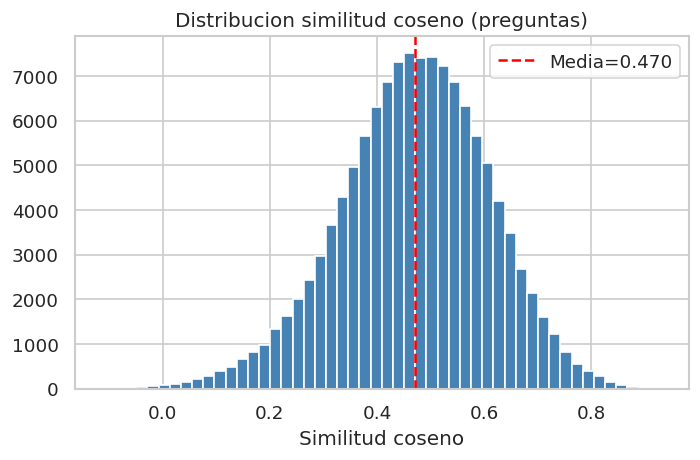

In [23]:
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
print('=' * 60)
print('GRUPO 4: SIMILITUD SEMANTICA')
print('=' * 60)


emb_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

sample_size = min(EMBEDDING_SAMPLE, total)
sample_idx = np.random.RandomState(42).choice(
    total, sample_size, replace=False)
sample_texts = df[COL_PREGUNTA].fillna('').iloc[sample_idx].tolist()

print(f'  Generando embeddings para {sample_size} preguntas...')
embeddings = emb_model.encode(
    sample_texts, show_progress_bar=True, batch_size=64)

sim_matrix = cosine_similarity(embeddings)
np.fill_diagonal(sim_matrix, 0)
mean_sim = sim_matrix.sum() / (sample_size * (sample_size - 1))

status_sim = 'OK' if mean_sim <= 0.70 else (
    'AMARILLO' if mean_sim <= 0.85 else 'ROJO')
print(f'  [{status_sim}] Similitud semantica promedio: {mean_sim:.4f} (umbral <= 0.70)')
REPORTE['sim_semantica'] = mean_sim

fig, ax = plt.subplots(figsize=(6, 4))
upper_tri = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]
ax.hist(upper_tri, bins=50, color='steelblue', edgecolor='white')
ax.axvline(mean_sim, color='red', linestyle='--',
           label=f'Media={mean_sim:.3f}')
ax.set_title('Distribucion similitud coseno (preguntas)')
ax.set_xlabel('Similitud coseno')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Balance de categorias (Grupo 5)
Referencia: Shannon (1948).

Se evalua el balance por **cultivo** cargado desde el JSON de estadisticas externo.  
Se usan dos metricas complementarias:
- **Entropia de Shannon Normalizada (Balance Score):** H_norm = H / log(k), donde k = numero de categorias. Valor 1.0 indica balance perfecto.
- **Coeficiente de Variacion (CV):** sigma / mu. Valor 0.0 indica balance perfecto; valores altos indican desbalance.

GRUPO 5: BALANCE DE CATEGORIAS POR CULTIVO

  --- Balance por cultivo (50 categorias en estadisticas) ---
    papa: 752 (10.9%)
    cacao: 688 (9.9%)
    general_y_policultivos: 642 (9.3%)
    tomate: 591 (8.5%)
    fríjol: 517 (7.5%)
    cítricos: 368 (5.3%)
    aguacate: 346 (5.0%)
    plátano_y_banano: 339 (4.9%)
    mango: 317 (4.6%)
    cebolla_y_ajo: 237 (3.4%)
    caucho: 226 (3.3%)
    algodón: 174 (2.5%)
    ají: 163 (2.4%)
    calabacín: 149 (2.2%)
    maíz: 132 (1.9%)
    ... y 35 categorias mas
  [OK] Entropia de Shannon Normalizada (Balance Score): 0.8011 (umbral >= 0.8)
    H = 3.1338 nats | H_max = 3.9120 nats | k = 50
  [ROJO] Coeficiente de Variacion (CV): 1.3996 (umbral <= 0.5)
    mu = 138.44 | sigma = 193.76


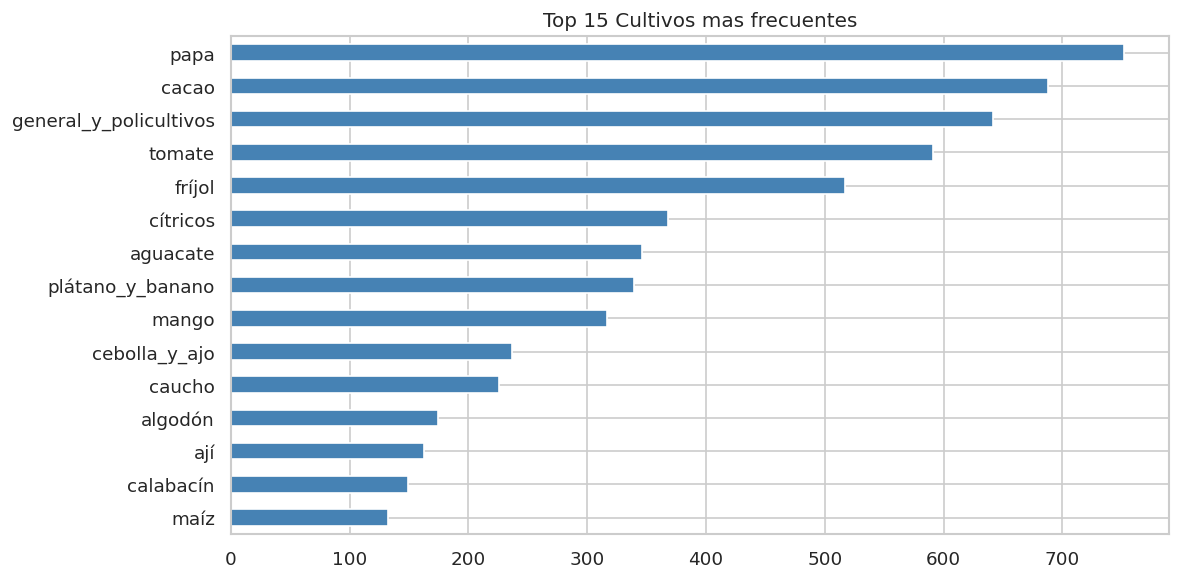

In [24]:
from scipy.stats import entropy as scipy_entropy

print('=' * 60)
print('GRUPO 5: BALANCE DE CATEGORIAS POR CULTIVO')
print('=' * 60)

counts_cultivo = pd.Series(crop_stats).sort_values(ascending=False)
total_stats = counts_cultivo.sum()
k = counts_cultivo.shape[0]  # numero de categorias

print(
    f'\n  --- Balance por cultivo ({k} categorias en estadisticas) ---')
for cat, cnt in counts_cultivo.head(15).items():
    print(f'    {cat}: {cnt} ({cnt/total_stats*100:.1f}%)')
if k > 15:
    print(f'    ... y {k - 15} categorias mas')

# --- Entropia de Shannon Normalizada (Balance Score) ---
# H_norm = H / log(k).  Rango [0, 1]. 1.0 = balance perfecto.
probs = counts_cultivo.values / total_stats
H = scipy_entropy(probs, base=np.e)   # entropia en nats
H_max = np.log(k) if k > 1 else 1.0
balance_score = H / H_max if H_max > 0 else 0.0

status_bs = 'OK' if balance_score >= 0.8 else (
    'AMARILLO' if balance_score >= 0.6 else 'ROJO')
print(f'  [{status_bs}] Entropia de Shannon Normalizada (Balance Score): {balance_score:.4f} (umbral >= 0.8)')
print(f'    H = {H:.4f} nats | H_max = {H_max:.4f} nats | k = {k}')

# --- Coeficiente de Variacion (CV) ---
# CV = sigma / mu.  Valor 0 = balance perfecto.
mu = counts_cultivo.mean()
sigma = counts_cultivo.std(ddof=0)
cv_cultivo = sigma / mu if mu > 0 else float('inf')

status_cv = 'OK' if cv_cultivo <= 0.5 else (
    'AMARILLO' if cv_cultivo <= 0.1 else 'ROJO')
print(f'  [{status_cv}] Coeficiente de Variacion (CV): {cv_cultivo:.4f} (umbral <= 0.5)')
print(f'    mu = {mu:.2f} | sigma = {sigma:.2f}')

REPORTE['balance_score'] = balance_score
REPORTE['cv_cultivo'] = cv_cultivo

# Grafico de barras
fig, ax = plt.subplots(figsize=(10, 5))
counts_cultivo.head(15).plot.barh(ax=ax, color='steelblue')
ax.set_title('Top 15 Cultivos mas frecuentes')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Complejidad de respuestas (Grupo 6)
Evalua la complejidad y estructura de las respuestas del asistente.

In [25]:
print('=' * 60)
print('GRUPO 6: COMPLEJIDAD DE RESPUESTAS')
print('=' * 60)


def analizar_complejidad_respuesta(row):
    answer = str(row[COL_ANSWER])
    reasoning = str(row[COL_REASONING])

    tok_answer = len(answer.split())
    tok_reasoning = len(reasoning.split())

    # Deteccion de listas
    tiene_lista = bool(re.search(r'(?:^|\n)\s*(?:\d+[.)\-]|[-*•])\s', answer))

    # Numero de oraciones aprox
    oraciones = len(re.split(r'[.!?]+', answer))

    # Ratio reasoning/answer
    ratio = tok_reasoning / tok_answer if tok_answer > 0 else 0

    # Nivel de complejidad
    score = 0
    if tok_answer > 100:
        score += 1
    if tiene_lista:
        score += 1
    if tok_reasoning > 50:
        score += 1
    if oraciones > 5:
        score += 1

    nivel = 'simple' if score <= 1 else ('medio' if score <= 2 else 'complejo')

    return {
        'tok_answer': tok_answer,
        'tok_reasoning': tok_reasoning,
        'tiene_lista': tiene_lista,
        'oraciones_answer': oraciones,
        'ratio_reasoning_answer': ratio,
        'score_complejidad': score,
        'nivel_complejidad': nivel,
    }


comp_df = pd.DataFrame([analizar_complejidad_respuesta(row) for _, row in
                        tqdm(df.iterrows(), total=total, desc='Analizando complejidad')])

for nv in ['simple', 'medio', 'complejo']:
    n = (comp_df['nivel_complejidad'] == nv).sum()
    print(f'  {nv.capitalize():10s}: {n:4d} ({n/total*100:.1f}%)')

print(f'  Tokens promedio answer:    {comp_df["tok_answer"].mean():.1f}')
print(f'  Tokens promedio reasoning: {comp_df["tok_reasoning"].mean():.1f}')
print(
    f'  Ratio reasoning/answer:    {comp_df["ratio_reasoning_answer"].mean():.2f}')
print(
    f'  Respuestas con listas:     {comp_df["tiene_lista"].sum()} ({comp_df["tiene_lista"].mean()*100:.1f}%)')

REPORTE['pct_simple'] = (comp_df['nivel_complejidad']
                         == 'simple').sum() / total
REPORTE['pct_medio'] = (comp_df['nivel_complejidad'] == 'medio').sum() / total
REPORTE['pct_complejo'] = (comp_df['nivel_complejidad']
                           == 'complejo').sum() / total

GRUPO 6: COMPLEJIDAD DE RESPUESTAS


Analizando complejidad:   0%|          | 0/6966 [00:00<?, ?it/s]

  Simple    :  145 (2.1%)
  Medio     :  439 (6.3%)
  Complejo  : 6382 (91.6%)
  Tokens promedio answer:    150.1
  Tokens promedio reasoning: 88.2
  Ratio reasoning/answer:    0.61
  Respuestas con listas:     172 (2.5%)


## 9. Validacion de formato - etiquetas reasoning/answer (Grupo 7)

Verifica que el mensaje del asistente contenga las etiquetas
`<reasoning>`, `</reasoning>`, `<answer>`, `</answer>` correctamente.

In [26]:
print('=' * 60)
print('GRUPO 7: VALIDACION DE FORMATO (ETIQUETAS XML)')
print('=' * 60)

errores_formato = []
n_ok = 0
tipos_error = Counter()

for idx, row in df.iterrows():
    assistant = str(row[COL_ASSISTANT])
    problemas = []

    # Verificar presencia de etiquetas
    if '<reasoning>' not in assistant:
        problemas.append('falta <reasoning>')
    if '</reasoning>' not in assistant:
        problemas.append('falta </reasoning>')
    if '<answer>' not in assistant:
        problemas.append('falta <answer>')
    if '</answer>' not in assistant:
        problemas.append('falta </answer>')

    # Verificar orden
    if not problemas:
        r_start = assistant.index('<reasoning>')
        r_end = assistant.index('</reasoning>')
        a_start = assistant.index('<answer>')
        a_end = assistant.index('</answer>')
        if not (r_start < r_end < a_start < a_end):
            problemas.append('orden incorrecto de etiquetas')

    # Verificar contenido no vacio
    if not problemas:
        reasoning_text = str(row[COL_REASONING]).strip()
        answer_text = str(row[COL_ANSWER]).strip()
        if len(reasoning_text) < 5:
            problemas.append('reasoning vacio o muy corto')
        if len(answer_text) < 5:
            problemas.append('answer vacio o muy corto')

    if problemas:
        for p in problemas:
            tipos_error[p] += 1
        errores_formato.append({'indice': idx, 'errores': problemas})
    else:
        n_ok += 1

tasa_errores = len(errores_formato) / total if total > 0 else 0
print(f'  [{"OK" if tasa_errores <= UMBRAL_FORMAT_ERROR else "WARN"}] Errores de formato: {len(errores_formato)} ({tasa_errores*100:.2f}%)')
print(f'  Registros validos: {n_ok} ({n_ok/total*100:.2f}%)')
REPORTE['tasa_errores_formato'] = tasa_errores

if tipos_error:
    print('  Tipos de error:')
    for e_type, count in tipos_error.most_common(10):
        print(f'    {e_type}: {count}')

GRUPO 7: VALIDACION DE FORMATO (ETIQUETAS XML)
  [OK] Errores de formato: 0 (0.00%)
  Registros validos: 6966 (100.00%)


## 10. Cobertura de vocabulario de dominio agricola (Grupo 8)
Referencia: Yu et al. ASE'24.

In [27]:
print('=' * 60)
print('GRUPO 8: COBERTURA DE VOCABULARIO DE DOMINIO AGRICOLA')
print('=' * 60)

tl = [t.lower() for t in TERMINOS_DOMINIO]


def detectar_terminos(texto):
    texto_l = str(texto).lower()
    return [t for t in tl if t in texto_l]


# Buscar en preguntas
df['terminos_dominio_pregunta'] = df[COL_PREGUNTA].apply(detectar_terminos)
df['n_terminos_dominio_pregunta'] = df['terminos_dominio_pregunta'].apply(len)

# Buscar en preguntas + respuestas
df['terminos_dominio_combinado'] = (df[COL_PREGUNTA].fillna(
    '') + ' ' + df[COL_ANSWER].fillna('')).apply(detectar_terminos)
df['n_terminos_dominio_combinado'] = df['terminos_dominio_combinado'].apply(
    len)

reg_con_q = (df['n_terminos_dominio_pregunta'] > 0).sum()
cob_q = reg_con_q / total
reg_con_c = (df['n_terminos_dominio_combinado'] > 0).sum()
cob_c = reg_con_c / total

print(f'  [{"OK" if cob_q >= 0.80 else "WARN"}] Cobertura en preguntas: {reg_con_q:,} ({cob_q*100:.1f}%)  (umbral >= 80%)')
print(f'  [{"OK" if cob_c >= 0.80 else "WARN"}] Cobertura combinada (pregunta+answer): {reg_con_c:,} ({cob_c*100:.1f}%)')
print(
    f'  Promedio terminos/pregunta: {df["n_terminos_dominio_pregunta"].mean():.2f}')

termino_freq = Counter()
for lista in df['terminos_dominio_combinado']:
    termino_freq.update(lista)
termino_df = pd.DataFrame(termino_freq.most_common(),
                          columns=['termino', 'freq'])
print(f'\n  Top 15 terminos:')
print(termino_df.head(15).to_string(index=False))

REPORTE['cobertura_dominio'] = cob_q
REPORTE['cobertura_dominio_combinada'] = cob_c

GRUPO 8: COBERTURA DE VOCABULARIO DE DOMINIO AGRICOLA
  [OK] Cobertura en preguntas: 6,560 (94.2%)  (umbral >= 80%)
  [OK] Cobertura combinada (pregunta+answer): 6,956 (99.9%)
  Promedio terminos/pregunta: 2.33

  Top 15 terminos:
   termino  freq
      mata  5431
    tierra  3534
      agua  3293
       era  2985
   parcela  1883
   cultivo  1830
enfermedad  1554
   semilla  1539
     plaga  1538
   cosecha  1527
     suelo  1471
       sca  1395
     abono  1268
     hongo  1266
       ota  1254


## 11. Self-BLEU y Self-ROUGE (Grupo 9)

Self-BLEU mide redundancia entre preguntas.  
Self-ROUGE-L mide redundancia en las respuestas del asistente.  
Referencia: Rangel et al. (2024), EMNLP 2024.

GRUPO 9: SELF-BLEU / SELF-ROUGE
  [WARN] Self-BLEU-2 (preguntas): 0.6825  (umbral <= 0.6)


Self-ROUGE-L (mean):   0%|          | 0/200 [00:00<?, ?it/s]

  Self-ROUGE-L respuestas (mean): 0.1624


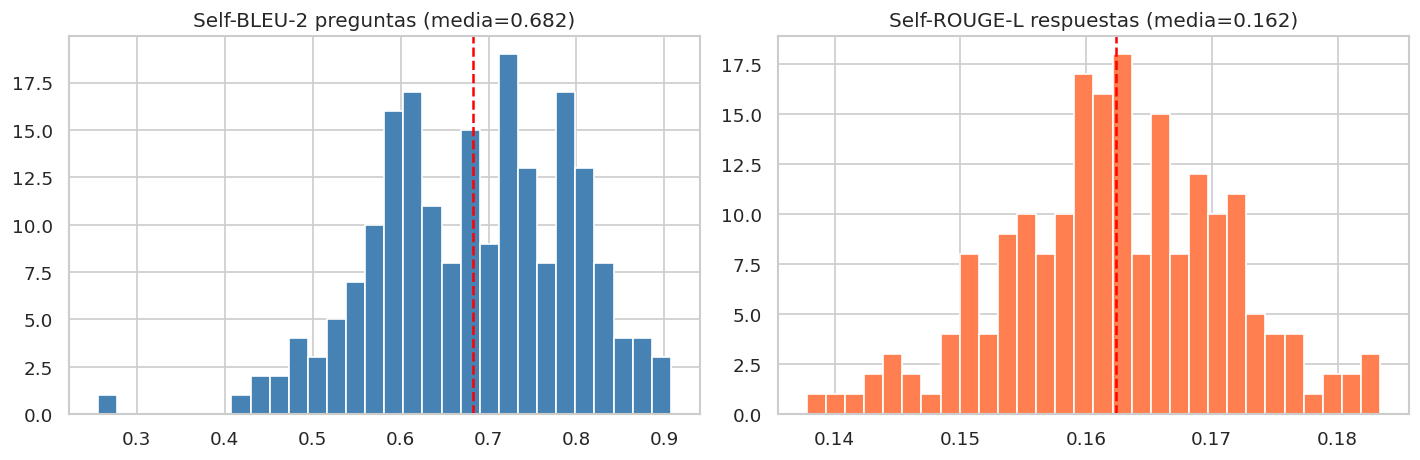

In [28]:
print('=' * 60)
print('GRUPO 9: SELF-BLEU / SELF-ROUGE')
print('=' * 60)

# Self-BLEU-2 sobre preguntas
sample_sb = min(SELF_BLEU_SAMPLE, total)
idx_sb = np.random.RandomState(42).choice(total, sample_sb, replace=False)
pregs_sample = [df[COL_PREGUNTA].fillna('').iloc[i].split() for i in idx_sb]

sf = SmoothingFunction().method1
bleu_scores = []
for i in range(len(pregs_sample)):
    refs = [pregs_sample[j] for j in range(len(pregs_sample)) if j != i]
    hyp = pregs_sample[i]
    if len(hyp) > 0:
        b = corpus_bleu([refs], [hyp], weights=(
            0.5, 0.5), smoothing_function=sf)
        bleu_scores.append(b)

self_bleu = np.mean(bleu_scores) if bleu_scores else 0
status_sb = 'OK' if self_bleu <= UMBRAL_SELF_BLEU_MAX else 'WARN'
print(f'  [{status_sb}] Self-BLEU-2 (preguntas): {self_bleu:.4f}  (umbral <= {UMBRAL_SELF_BLEU_MAX})')
REPORTE['self_bleu'] = self_bleu

# Self-ROUGE-L sobre respuestas
scorer_rl = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
answers_sample = [df[COL_ANSWER].fillna('').iloc[i] for i in idx_sb]

rouge_scores = []
for i in tqdm(range(len(answers_sample)), desc='Self-ROUGE-L (mean)'):
    pairwise = []
    for j in range(len(answers_sample)):
        if j != i:
            sc = scorer_rl.score(answers_sample[i], answers_sample[j])
            pairwise.append(sc['rougeL'].fmeasure)
    if pairwise:
        rouge_scores.append(np.mean(pairwise))

self_rouge = np.mean(rouge_scores) if rouge_scores else 0
print(f'  Self-ROUGE-L respuestas (mean): {self_rouge:.4f}')
REPORTE['self_rouge'] = self_rouge

# Graficos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(bleu_scores, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(self_bleu, color='red', linestyle='--')
axes[0].set_title(f'Self-BLEU-2 preguntas (media={self_bleu:.3f})')
axes[1].hist(rouge_scores, bins=30, color='coral', edgecolor='white')
axes[1].axvline(self_rouge, color='red', linestyle='--')
axes[1].set_title(f'Self-ROUGE-L respuestas (media={self_rouge:.3f})')
plt.tight_layout()
plt.show()

## 12. Scorecard de metricas

In [32]:
print('=' * 60)
print('SCORECARD DE CALIDAD')
print('=' * 60)


def semaforo(val, green_fn, yellow_fn):
    """Retorna VERDE/AMARILLO/ROJO segun funciones de umbral."""
    if green_fn(val):
        return '🟢 VERDE'
    if yellow_fn(val):
        return '🟡 AMARILLO'
    return '🔴 ROJO'


metricas = [
    ('Tasa malformados',       f"{REPORTE.get('tasa_malformados', 0)*100:.2f}%",
     semaforo(REPORTE.get('tasa_malformados', 0), lambda v: v <= 0.01, lambda v: v <= 0.05)),
    ('Duplicados exactos',     f"{REPORTE.get('dup_exactos', 0)*100:.2f}%",
     semaforo(REPORTE.get('dup_exactos', 0), lambda v: v <= 0.01, lambda v: v <= 0.05)),
    ('Near-duplicates',        f"{REPORTE.get('near_dup', 0)*100:.2f}%",
     semaforo(REPORTE.get('near_dup', 0), lambda v: v <= 0.05, lambda v: v <= 0.10)),
]

if 'mtld_preguntas' in REPORTE:
    metricas.append(('MTLD preguntas', f"{REPORTE['mtld_preguntas']:.2f}",
                     semaforo(REPORTE['mtld_preguntas'], lambda v: v >= 40, lambda v: v >= 20)))
if 'mtld_respuestas' in REPORTE:
    metricas.append(('MTLD respuestas', f"{REPORTE['mtld_respuestas']:.2f}",
                     semaforo(REPORTE['mtld_respuestas'], lambda v: v >= 40, lambda v: v >= 20)))

metricas += [
    ('Bigram diversity preg.',  f"{REPORTE.get('bigram_div_preguntas', 0):.4f}",
     semaforo(REPORTE.get('bigram_div_preguntas', 0), lambda v: v >= 0.75, lambda v: v >= 0.60)),
    ('Sim. semantica prom.',    f"{REPORTE.get('sim_semantica', 0):.4f}",
     semaforo(REPORTE.get('sim_semantica', 0), lambda v: v <= 0.70, lambda v: v <= 0.85)),
    ('Balance Score (H_norm)',  f"{REPORTE.get('balance_score', 0):.4f}",
     semaforo(REPORTE.get('balance_score', 0), lambda v: v >= 0.8, lambda v: v >= 0.60)),
    ('CV cultivo',              f"{REPORTE.get('cv_cultivo', 0):.4f}",
     semaforo(REPORTE.get('cv_cultivo', 0), lambda v: v <= 0.5, lambda v: v <= 0.1)),
    ('Error formato XML',       f"{REPORTE.get('tasa_errores_formato', 0)*100:.2f}%",
     semaforo(REPORTE.get('tasa_errores_formato', 0), lambda v: v <= 0.00, lambda v: v <= 0.02)),
    ('Cobertura dominio',       f"{REPORTE.get('cobertura_dominio', 0)*100:.1f}%",
     semaforo(REPORTE.get('cobertura_dominio', 0), lambda v: v >= 0.80, lambda v: v >= 0.60)),
    ('Self-BLEU-2 preguntas',   f"{REPORTE.get('self_bleu', 0):.4f}",
     semaforo(REPORTE.get('self_bleu', 0), lambda v: v <= 0.30, lambda v: v <= 0.60)),
    ('Self-ROUGE-L respuestas', f"{REPORTE.get('self_rouge', 0):.4f}",
     semaforo(REPORTE.get('self_rouge', 0), lambda v: v <= 0.50, lambda v: v <= 0.75)),
]

scorecard_df = pd.DataFrame(metricas, columns=['Metrica', 'Valor', 'Estado'])
print(scorecard_df.to_string(index=False))

# Score global
conteo = Counter()
for _, r in scorecard_df.iterrows():
    if 'VERDE' in r['Estado']:
        conteo['VERDE'] += 1
    elif 'AMARILLO' in r['Estado']:
        conteo['AMARILLO'] += 1
    else:
        conteo['ROJO'] += 1

n_met = len(scorecard_df)
score_global = (conteo['VERDE'] * 100 + conteo['AMARILLO']
                * 50) / n_met if n_met > 0 else 0
print(f'\n  SCORE GLOBAL: {score_global:.1f}/100')
print(
    f'  VERDE: {conteo["VERDE"]}  |  AMARILLO: {conteo["AMARILLO"]}  |  ROJO: {conteo["ROJO"]}')

# Recomendaciones
recomendaciones = []
if REPORTE.get('tasa_malformados', 0) > 0.01:
    recomendaciones.append(
        'Revisar y corregir registros con estructura ChatML malformada.')
if REPORTE.get('dup_exactos', 0) > 0.01:
    recomendaciones.append('Eliminar duplicados exactos del dataset.')
if REPORTE.get('near_dup', 0) > 0.05:
    recomendaciones.append(
        'Revisar near-duplicates: posible generacion con plantillas.')
if REPORTE.get('bigram_div_preguntas', 0) < 0.70:
    recomendaciones.append(
        'Aumentar diversidad de formulacion en las preguntas.')
if REPORTE.get('sim_semantica', 0) > 0.70:
    recomendaciones.append(
        'Diversificar temas de las preguntas: alta similitud semantica.')
if REPORTE.get('balance_score', 1) < 0.6:
    recomendaciones.append(
        'Desbalance severo entre cultivos: aumentar registros de categorias sub-representadas.')
if REPORTE.get('cv_cultivo', 0) > 0.1:
    recomendaciones.append(
        'Alta variabilidad entre cultivos (CV alto): equilibrar la cantidad de registros por categoria.')
if REPORTE.get('tasa_errores_formato', 0) > 0:
    recomendaciones.append(
        'Corregir etiquetas <reasoning>/<answer> malformadas.')
if REPORTE.get('cobertura_dominio', 0) < 0.80:
    recomendaciones.append(
        'Aumentar preguntas con vocabulario del dominio agricola.')
if REPORTE.get('self_bleu', 0) > 0.60:
    recomendaciones.append(
        'Self-BLEU alto: las preguntas son muy similares entre si.')
if REPORTE.get('self_rouge', 0) > 0.50:
    recomendaciones.append(
        'Self-ROUGE alto: las respuestas se repiten demasiado.')

if recomendaciones:
    print('\n  Recomendaciones:')
    for r in recomendaciones:
        print(f'    - {r}')
else:
    print('\n  Sin recomendaciones criticas.')

SCORECARD DE CALIDAD
                Metrica  Valor  Estado
       Tasa malformados  0.00% 🟢 VERDE
     Duplicados exactos  0.00% 🟢 VERDE
        Near-duplicates  0.17% 🟢 VERDE
         MTLD preguntas  74.19 🟢 VERDE
        MTLD respuestas  92.84 🟢 VERDE
 Bigram diversity preg. 0.2185  🔴 ROJO
   Sim. semantica prom. 0.4700 🟢 VERDE
 Balance Score (H_norm) 0.8011 🟢 VERDE
             CV cultivo 1.3996  🔴 ROJO
      Error formato XML  0.00% 🟢 VERDE
      Cobertura dominio  94.2% 🟢 VERDE
  Self-BLEU-2 preguntas 0.6825  🔴 ROJO
Self-ROUGE-L respuestas 0.1624 🟢 VERDE

  SCORE GLOBAL: 76.9/100
  VERDE: 10  |  AMARILLO: 0  |  ROJO: 3

  Recomendaciones:
    - Aumentar diversidad de formulacion en las preguntas.
    - Alta variabilidad entre cultivos (CV alto): equilibrar la cantidad de registros por categoria.
    - Self-BLEU alto: las preguntas son muy similares entre si.


## 13. Exportacion de resultados

Genera `dataset_quality_report.csv`, `dataset_con_metricas.csv` y `dataset_quality_report.html`.

In [33]:
ts = datetime.datetime.now().strftime('%Y-%m-%d %H:%M')

# 1. Scorecard CSV
scorecard_df.to_csv('dataset_quality_report.csv',
                    index=False, encoding='utf-8-sig')
print('Exportado: dataset_quality_report.csv')

# 2. Dataset con metricas CSV
cols_base = [COL_PREGUNTA, COL_ANSWER, COL_REASONING, COL_KNOWLEDGE,
             'len_pregunta', 'tokens_pregunta', 'len_answer', 'tokens_answer',
             'len_reasoning', 'tokens_reasoning',
             'n_terminos_dominio_pregunta', 'hash']

df_export = df[[c for c in cols_base if c in df.columns]
               ].reset_index(drop=True)
if comp_df is not None:
    cols_comp = ['nivel_complejidad', 'score_complejidad',
                 'ratio_reasoning_answer', 'tiene_lista']
    cols_ok = [c for c in cols_comp if c in comp_df.columns]
    df_export = pd.concat(
        [df_export, comp_df[cols_ok].reset_index(drop=True)], axis=1)

df_export.to_csv('dataset_con_metricas.csv', index=False, encoding='utf-8-sig')
print('Exportado: dataset_con_metricas.csv')

# 3. Reporte HTML
DESC_MAP = {
    'Tasa malformados':         'Registros con estructura ChatML rota o campos vacios',
    'Duplicados exactos':       'Misma pregunta y misma respuesta',
    'Near-duplicates':          'Preguntas casi identicas (Jaccard >= 0.80)',
    'MTLD preguntas':           'Riqueza lexica de las preguntas (McCarthy & Jarvis 2010)',
    'MTLD respuestas':          'Riqueza lexica de las respuestas',
    'Bigram diversity preg.':   'Pares de palabras unicos / total pares en preguntas',
    'Sim. semantica prom.':     'Coseno promedio entre embeddings de preguntas',
    'Balance Score (H_norm)':   'Entropia de Shannon normalizada: 1.0 = balance perfecto (Shannon 1948)',
    'CV cultivo':               'Coeficiente de variacion entre cultivos: 0 = balance perfecto',
    'Error formato XML':        'Respuestas sin etiquetas <reasoning>/<answer> correctas',
    'Cobertura dominio':        'Preguntas con al menos un termino agricola del dominio',
    'Self-BLEU-2 preguntas':    'Que tanto se copian las preguntas entre si',
    'Self-ROUGE-L respuestas':  'Que tan repetidas son las respuestas del asistente',
}

trs = ''
for _, r in scorecard_df.iterrows():
    nombre = r['Metrica']
    estado_str = str(r['Estado'])
    badge_cls = 'v' if 'VERDE' in estado_str else (
        'a' if 'AMARILLO' in estado_str else 'r')
    badge_label = (estado_str
                   .replace('\U0001f7e2', '').replace('\U0001f7e1', '').replace('\U0001f534', '')
                   .strip())
    desc = DESC_MAP.get(nombre, '')
    metrica_cell = (
        f'<b>{nombre}</b>'
        f'<br><span style="font-size:0.82em;color:#777;font-style:italic">{desc}</span>'
    )
    valor_cell = (
        f'<span style="font-size:1.15em;font-weight:bold">{r["Valor"]}</span>'
        f'<br><span class="badge {badge_cls}" style="font-size:0.78em;padding:3px 10px">{badge_label}</span>'
    )
    trs += (
        f'<tr>'
        f'<td style="width:22%;vertical-align:top">{metrica_cell}</td>'
        f'<td style="width:15%;text-align:center;vertical-align:middle">{valor_cell}</td>'
        f'</tr>\n'
    )

rec_li = '\n'.join(
    f'<li>{r}</li>' for r in recomendaciones) if recomendaciones else '<li>Ninguna critica.</li>'

html_content = f"""<!DOCTYPE html>
<html lang='es'><head><meta charset='UTF-8'>
<title>Reporte Calidad Dataset ChatML Agricola</title>
<style>
  body      {{ font-family: Arial, sans-serif; margin: 2em; background: #f5f5f5; color: #333; }}
  h1        {{ color: #1d3557; }}
  h2        {{ color: #457b9d; margin-top: 2em; }}
  table     {{ border-collapse: collapse; width: 100%; background: #fff; box-shadow: 0 1px 4px #ccc; }}
  th        {{ background: #1d3557; color: #fff; padding: 10px 14px; text-align: left;
               font-size: 0.88em; letter-spacing: 0.06em; text-transform: uppercase; }}
  td        {{ padding: 10px 14px; border-bottom: 1px solid #e0e0e0; }}
  tr:hover  {{ background: #f0f4ff; }}
  ul        {{ margin: 0; padding-left: 1.3em; }}
  li        {{ margin-bottom: 4px; }}
  .score    {{ font-size: 2.5em; font-weight: bold; color: #1d3557; }}
  .badge    {{ display: inline-block; padding: 4px 13px; border-radius: 6px;
               color: #fff; font-weight: bold; }}
  .v        {{ background: #2d6a4f; }}
  .a        {{ background: #e76f51; }}
  .r        {{ background: #c1121f; }}
</style>
</head><body>
<h1>Reporte de Calidad - Dataset ChatML para SLMs Agricolas</h1>
<p>
  <b>Proyecto:</b> FarmifAI - Asistente Virtual Agricola - Universidad del Cauca<br>
  <b>Generado:</b> {ts} &nbsp;|&nbsp; <b>Version:</b> 4.0 (ChatML &amp; Estadisticas JSON) &nbsp;|&nbsp;
  <b>Total registros:</b> {total:,}
</p>
<div class='score'>{score_global:.1f}/100</div>
<p>
  <span class='badge v'>VERDE: {conteo['VERDE']}</span>&nbsp;
  <span class='badge a'>AMARILLO: {conteo['AMARILLO']}</span>&nbsp;
  <span class='badge r'>ROJO: {conteo['ROJO']}</span>
</p>
<h2>Scorecard de metricas</h2>
<table>
  <thead>
    <tr>
      <th>Metrica</th>
      <th>Valor actual</th>
    </tr>
  </thead>
  <tbody>{trs}</tbody>
</table>
<h2>Recomendaciones</h2>
<ul>{rec_li}</ul>
<h2>Notas metodologicas</h2>
<ul>
  <li>MTLD es la metrica primaria de riqueza lexica (McCarthy &amp; Jarvis, 2010).</li>
  <li>Self-ROUGE-L usa mean (no max) para evitar sobreestimacion (Rangel et al. 2024).</li>
  <li>Estructura ChatML validada: system/user/assistant con etiquetas reasoning/answer.</li>
  <li>Cobertura de dominio evaluada contra {len(TERMINOS_DOMINIO)} terminos agricolas.</li>
  <li>Estadisticas de cultivos integradas externamente desde JSON.</li>
</ul>
</body></html>"""

with open('dataset_quality_report.html', 'w', encoding='utf-8') as f:
    f.write(html_content)
print('Exportado: dataset_quality_report.html')

try:
    from google.colab import files
    files.download('dataset_quality_report.csv')
    files.download('dataset_quality_report.html')
    files.download('dataset_con_metricas.csv')
except Exception:
    print('[INFO] Descarga manual: usar el panel de archivos de Colab.')

Exportado: dataset_quality_report.csv
Exportado: dataset_con_metricas.csv
Exportado: dataset_quality_report.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Apendice: Umbrales y bibliografia

| Metrica | Umbral verde | Umbral amarillo | Fuente |
|---|---|---|---|
| Duplicados exactos | <= 1% | <= 5% | Lee et al. ACL 2022 |
| Near-duplicates (Jaccard >= 0.8) | <= 5% | <= 10% | Abbas et al. ICLR 2023 |
| MTLD (metrica primaria) | >= 40 | >= 20 | McCarthy & Jarvis (2010) |
| Bigram diversity | >= 0.75 | >= 0.60 | arXiv:2502.17184 |
| Similitud semantica promedio | <= 0.70 | <= 0.85 | arXiv:2502.17184 |
| Balance Score H_norm (cultivo) | >= 0.8 | >= 0.6 | Shannon (1948);
| Coeficiente de Variacion CV (cultivo) | <= 0.5 | <= 0.1 |
| Errores formato XML | 0% | <= 2% | Validacion interna |
| Cobertura terminos dominio | >= 80% | >= 60% | Yu et al. ASE'24 |
| Self-BLEU-2 preguntas | <= 0.30 | <= 0.60 | EMNLP 2024 |
| Self-ROUGE-L respuestas (mean) | <= 0.50 | <= 0.75 | Rangel et al. arXiv:2402.04627 |

## Referencias bibliograficas

1. McCarthy, P.M. & Jarvis, S. (2010). MTLD, vocd-D, and HD-D. *Behav Res Methods*, 42(2):381-392.
2. Lee, K. et al. (2022). Deduplicating Training Data. *ACL 2022*.
3. Abbas, A. et al. (2023). SemDedup. *ICLR 2023*. arXiv:2303.09540
4. (2025). Measuring Data Diversity for Instruction Tuning. arXiv:2502.17184
5. Rangel, J.C. et al. (2024). SPARQL Generation fine-tuning. arXiv:2402.04627
6. EMNLP 2024. Quality Matters: Synthetic Data. aclanthology.org/2024.emnlp-main.285
7. (2024). Small Language Models: Survey. arXiv:2409.15790
8. Sajith, A. & Kathala, K. (2024). Training Data Quality vs Quantity. arXiv:2411.15821
9. Yu, X. et al. (2024). 18 Characteristics of High-Quality Datasets. *ASE'24*.